# NYC Taxi Fleet Analysis — Borough Cab Co.
## Google Colab Notebook

**Project:** Q1 2022 Yellow Taxi Trip Analysis  
**Tools:** Python, Pandas, Matplotlib, Seaborn, BigQuery  
**Author:** Angela  
**Date:** 2026

### Overview
This notebook connects to BigQuery to pull aggregated taxi trip data
and produces visualizations supporting the Borough Cab Co. analysis.
It validates key findings from the SQL analysis and provides deeper
visual exploration of trip patterns, revenue trends, and operational insights.


In [ ]:
# ============================================================
# Setup and Authentication
# ============================================================

# Authenticate with Google — this will prompt you to log in
from google.colab import auth
auth.authenticate_user()

# Import libraries
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize BigQuery client
# Replace with your actual BigQuery project ID
project_id = 'nyc-taxi-fleet-analysis'
client = bigquery.Client(project=project_id)

print("Successfully connected to BigQuery!")


Successfully connected to BigQuery!


In [ ]:
# ============================================================
# Section 1: Load Aggregated Data from BigQuery
# ============================================================

# --- 1.1 Monthly Trends ---
monthly_query = """
SELECT
  EXTRACT(MONTH FROM pickup_datetime)                 AS month_num,
  FORMAT_TIMESTAMP('%B', pickup_datetime)             AS month_name,
  COUNT(*)                                            AS total_trips,
  ROUND(SUM(total_amount), 2)                         AS total_revenue,
  ROUND(AVG(total_amount), 2)                         AS avg_revenue_per_trip,
  ROUND(AVG(fare_amount), 2)                          AS avg_fare,
  ROUND(AVG(tip_amount), 2)                           AS avg_tip
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
WHERE
  EXTRACT(YEAR FROM pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
  AND fare_amount > 0
  AND trip_distance > 0
  AND passenger_count > 0
  AND dropoff_datetime > pickup_datetime
GROUP BY
  month_num,
  month_name
ORDER BY
  month_num
"""

# --- 1.2 Day of Week ---
dow_query = """
SELECT
  EXTRACT(DAYOFWEEK FROM pickup_datetime)             AS day_num,
  FORMAT_TIMESTAMP('%A', pickup_datetime)             AS day_name,
  COUNT(*)                                            AS total_trips,
  ROUND(SUM(total_amount), 2)                         AS total_revenue,
  ROUND(AVG(total_amount), 2)                         AS avg_revenue_per_trip,
  ROUND(AVG(tip_amount), 2)                           AS avg_tip
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
WHERE
  EXTRACT(YEAR FROM pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
  AND fare_amount > 0
  AND trip_distance > 0
  AND passenger_count > 0
  AND dropoff_datetime > pickup_datetime
GROUP BY
  day_num,
  day_name
ORDER BY
  day_num
"""

# --- 1.3 Hour of Day ---
hour_query = """
SELECT
  EXTRACT(HOUR FROM pickup_datetime)                  AS hour_of_day,
  COUNT(*)                                            AS total_trips,
  ROUND(SUM(total_amount), 2)                         AS total_revenue,
  ROUND(AVG(total_amount), 2)                         AS avg_revenue_per_trip,
  ROUND(AVG(tip_amount), 2)                           AS avg_tip
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
WHERE
  EXTRACT(YEAR FROM pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
  AND fare_amount > 0
  AND trip_distance > 0
  AND passenger_count > 0
  AND dropoff_datetime > pickup_datetime
GROUP BY
  hour_of_day
ORDER BY
  hour_of_day
"""

# --- 1.4 Borough Revenue ---
borough_query = """
SELECT
  z.borough,
  COUNT(*)                                            AS total_trips,
  ROUND(SUM(t.total_amount), 2)                       AS total_revenue,
  ROUND(AVG(t.total_amount), 2)                       AS avg_revenue_per_trip,
  ROUND(AVG(t.tip_amount), 2)                         AS avg_tip
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022` t
JOIN
  `bigquery-public-data.new_york_taxi_trips.taxi_zone_geom` z
  ON t.pickup_location_id = z.zone_id
WHERE
  EXTRACT(YEAR FROM t.pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM t.pickup_datetime) IN (1, 2, 3)
  AND t.fare_amount > 0
  AND t.trip_distance > 0
  AND t.passenger_count > 0
  AND t.dropoff_datetime > t.pickup_datetime
GROUP BY
  z.borough
ORDER BY
  total_revenue DESC
"""

# --- 1.5 Payment Type by Borough ---
payment_query = """
SELECT
  z.borough,
  CASE t.payment_type
    WHEN '1' THEN 'Credit Card'
    WHEN '2' THEN 'Cash'
    WHEN '3' THEN 'No Charge'
    WHEN '4' THEN 'Dispute'
    ELSE           'Unknown'
  END                                                 AS payment_label,
  COUNT(*)                                            AS total_trips,
  ROUND(SUM(t.total_amount), 2)                       AS total_revenue,
  ROUND(AVG(t.total_amount), 2)                       AS avg_revenue_per_trip,
  ROUND(AVG(t.tip_amount), 2)                         AS avg_tip
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022` t
JOIN
  `bigquery-public-data.new_york_taxi_trips.taxi_zone_geom` z
  ON t.pickup_location_id = z.zone_id
WHERE
  EXTRACT(YEAR FROM t.pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM t.pickup_datetime) IN (1, 2, 3)
  AND t.fare_amount > 0
  AND t.trip_distance > 0
  AND t.passenger_count > 0
  AND t.dropoff_datetime > t.pickup_datetime
  AND t.payment_type IN ('1', '2')
GROUP BY
  z.borough,
  payment_label
ORDER BY
  z.borough,
  total_trips DESC
"""

# Run all queries and load into dataframes
print("Loading data from BigQuery...")

df_monthly = client.query(monthly_query).to_dataframe()
print("✓ Monthly trends loaded")

df_dow = client.query(dow_query).to_dataframe()
print("✓ Day of week loaded")

df_hour = client.query(hour_query).to_dataframe()
print("✓ Hour of day loaded")

df_borough = client.query(borough_query).to_dataframe()
print("✓ Borough revenue loaded")

df_payment = client.query(payment_query).to_dataframe()
print("✓ Payment type by borough loaded")

print("\nAll datasets loaded successfully!")

Loading data from BigQuery...
✓ Monthly trends loaded
✓ Day of week loaded
✓ Hour of day loaded
✓ Borough revenue loaded
✓ Payment type by borough loaded

All datasets loaded successfully!


## Section 2: Visualizations

### 2.1 Monthly Revenue Trend
Q1 2022 showed consistent growth across all three months,
reflecting NYC's post-Omicron recovery pattern.

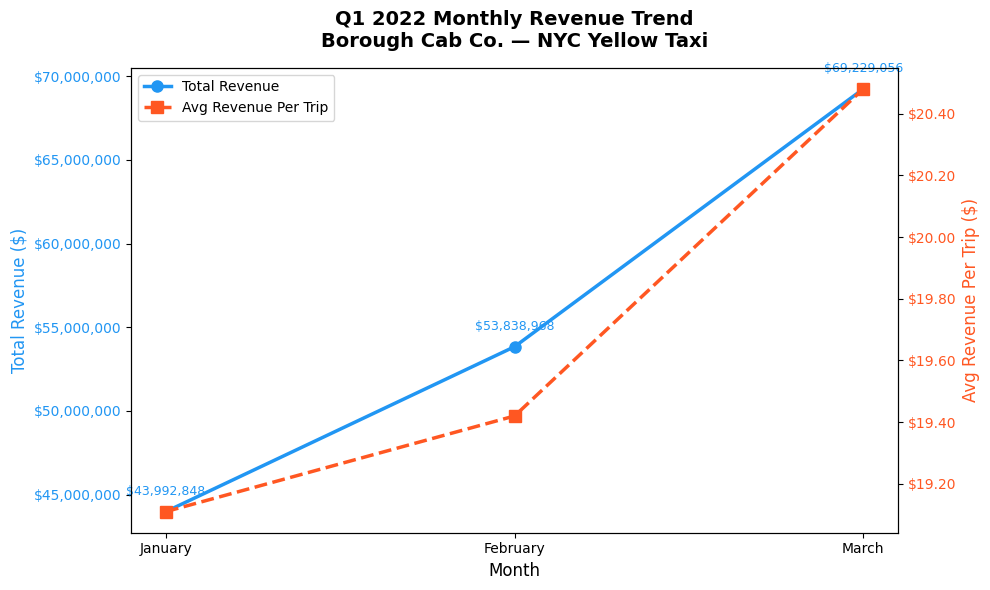

Chart saved as monthly_revenue_trend.png


In [ ]:
# ============================================================
# Section 2.1: Monthly Revenue Trend — Line Chart
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Line 1: Total Revenue (left axis) ---
color_revenue = '#2196F3'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', color=color_revenue, fontsize=12)
ax1.plot(
    df_monthly['month_name'],
    df_monthly['total_revenue'],
    color=color_revenue,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Total Revenue'
)
ax1.tick_params(axis='y', labelcolor=color_revenue)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# --- Line 2: Avg Revenue Per Trip (right axis) ---
ax2 = ax1.twinx()
color_avg = '#FF5722'
ax2.set_ylabel('Avg Revenue Per Trip ($)', color=color_avg, fontsize=12)
ax2.plot(
    df_monthly['month_name'],
    df_monthly['avg_revenue_per_trip'],
    color=color_avg,
    marker='s',
    linewidth=2.5,
    markersize=8,
    linestyle='--',
    label='Avg Revenue Per Trip'
)
ax2.tick_params(axis='y', labelcolor=color_avg)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:.2f}')
)

# --- Labels and annotations ---
for i, row in df_monthly.iterrows():
    ax1.annotate(
        f"${row['total_revenue']:,.0f}",
        xy=(row['month_name'], row['total_revenue']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        color=color_revenue
    )

# --- Title and legend ---
plt.title(
    'Q1 2022 Monthly Revenue Trend\nBorough Cab Co. — NYC Yellow Taxi',
    fontsize=14,
    fontweight='bold',
    pad=15
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as monthly_revenue_trend.png")


### 2.2 Total Trips and Revenue by Borough
Comparing borough performance reveals the tension between
volume-driven and value-driven revenue generation.

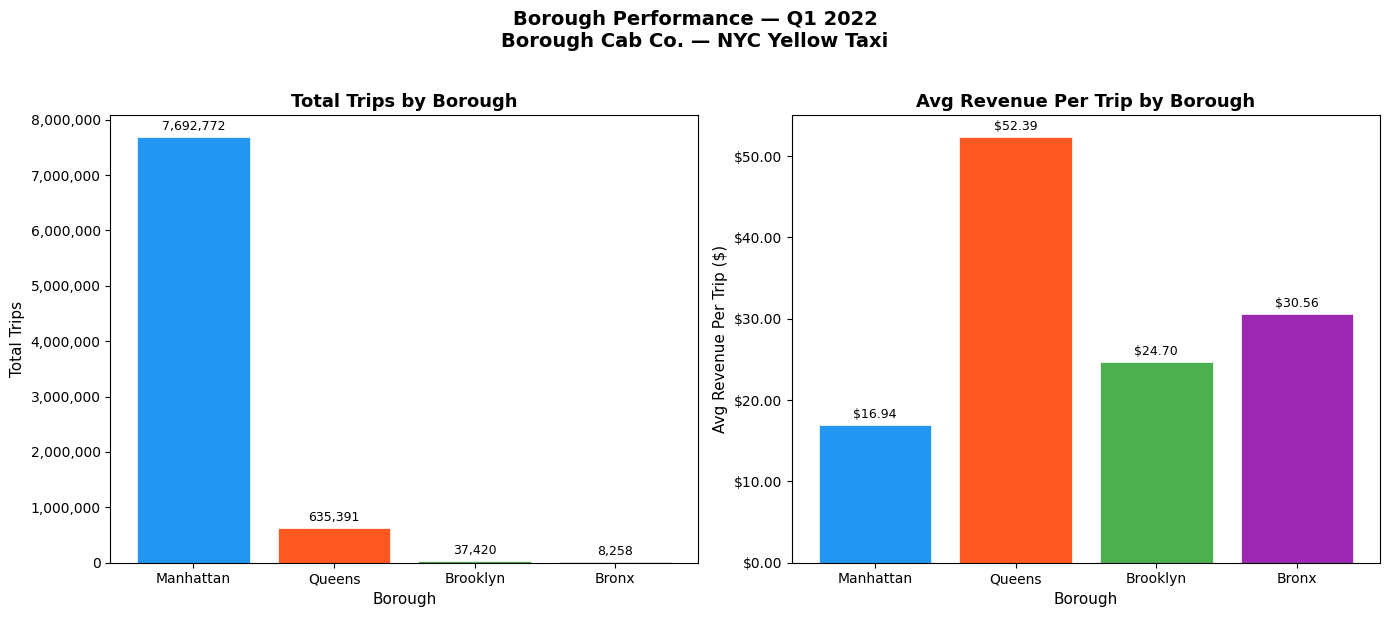

Chart saved as borough_performance.png


In [ ]:
# ============================================================
# Section 2.2: Borough Performance — Side by Side Bar Charts
# ============================================================

# Filter out EWR and Staten Island for cleaner visualization
# Small sample sizes make them visual outliers
df_borough_main = df_borough[
    ~df_borough['borough'].isin(['EWR', 'Staten Island'])
].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

# --- Left chart: Total Trips ---
bars1 = ax1.bar(
    df_borough_main['borough'],
    df_borough_main['total_trips'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
ax1.set_title('Total Trips by Borough', fontsize=13, fontweight='bold')
ax1.set_xlabel('Borough', fontsize=11)
ax1.set_ylabel('Total Trips', fontsize=11)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Add value labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

# --- Right chart: Avg Revenue Per Trip ---
bars2 = ax2.bar(
    df_borough_main['borough'],
    df_borough_main['avg_revenue_per_trip'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
ax2.set_title('Avg Revenue Per Trip by Borough', fontsize=13, fontweight='bold')
ax2.set_xlabel('Borough', fontsize=11)
ax2.set_ylabel('Avg Revenue Per Trip ($)', fontsize=11)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:.2f}')
)

# Add value labels on top of each bar
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(
        f'${height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

# --- Overall title ---
fig.suptitle(
    'Borough Performance — Q1 2022\nBorough Cab Co. — NYC Yellow Taxi',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('borough_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as borough_performance.png")

### 2.3 Trip Demand Heatmap — Hour of Day vs Day of Week
Combining hourly and daily patterns reveals exactly when
driver supply should be highest to meet peak demand.

Loading heatmap data from BigQuery...
✓ Heatmap data loaded


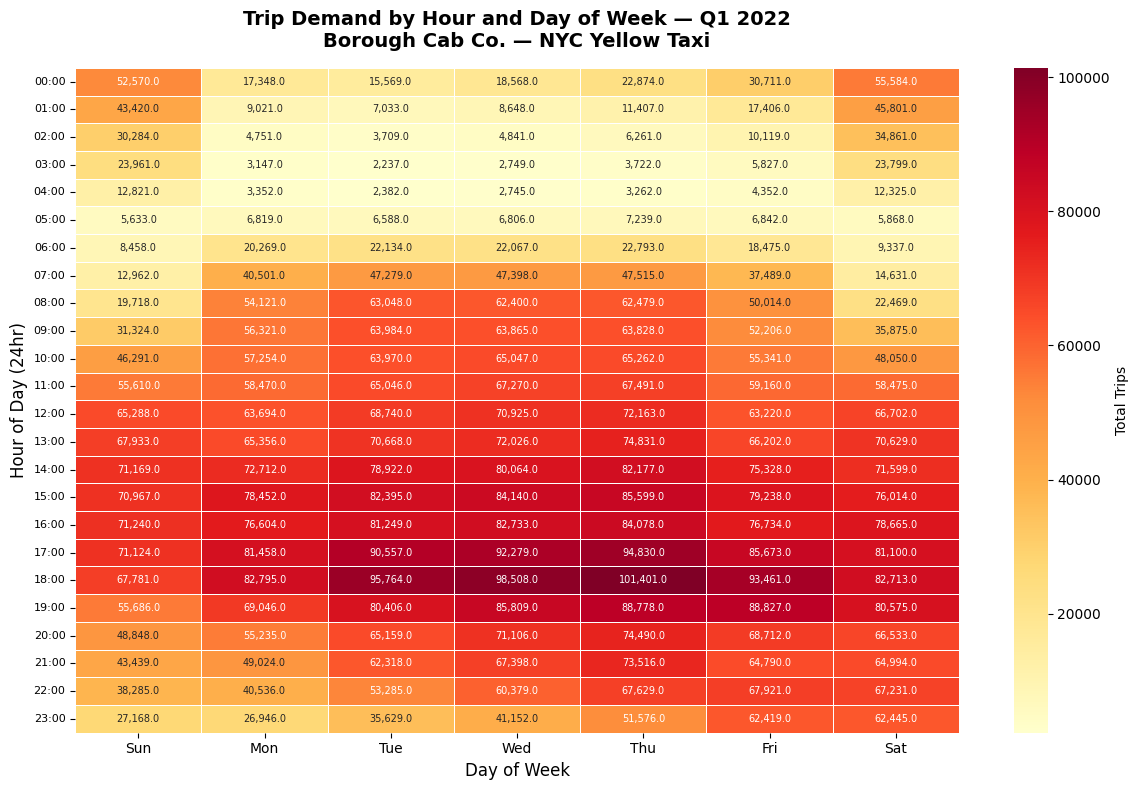

Chart saved as demand_heatmap.png


In [ ]:
# ============================================================
# Section 2.3: Demand Heatmap — Hour of Day vs Day of Week
# ============================================================

# Pull a combined hour + day of week query from BigQuery
heatmap_query = """
SELECT
  EXTRACT(DAYOFWEEK FROM pickup_datetime)             AS day_num,
  FORMAT_TIMESTAMP('%a', pickup_datetime)             AS day_name,
  EXTRACT(HOUR FROM pickup_datetime)                  AS hour_of_day,
  COUNT(*)                                            AS total_trips
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
WHERE
  EXTRACT(YEAR FROM pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
  AND fare_amount > 0
  AND trip_distance > 0
  AND passenger_count > 0
  AND dropoff_datetime > pickup_datetime
GROUP BY
  day_num,
  day_name,
  hour_of_day
ORDER BY
  day_num,
  hour_of_day
"""

print("Loading heatmap data from BigQuery...")
df_heatmap = client.query(heatmap_query).to_dataframe()
print("✓ Heatmap data loaded")

# Pivot into a matrix — rows = hours, columns = days
day_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

heatmap_pivot = df_heatmap.pivot_table(
    index='hour_of_day',
    columns='day_name',
    values='total_trips',
    aggfunc='sum'
)[day_order].astype(float)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap='YlOrRd',
    fmt=',',
    annot=True,
    annot_kws={'size': 7},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Total Trips'}
)

ax.set_title(
    'Trip Demand by Hour and Day of Week — Q1 2022\nBorough Cab Co. — NYC Yellow Taxi',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Hour of Day (24hr)', fontsize=12)

# Format y axis labels as readable times
hour_labels = [f'{h:02d}:00' for h in range(24)]
ax.set_yticklabels(hour_labels, rotation=0, fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('demand_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as demand_heatmap.png")

### 2.4 Trip Distance vs Tip Amount
Exploring the relationship between trip distance and tip
behavior to understand what drives passenger generosity.

Loading scatter plot sample from BigQuery...
✓ Loaded 10,000 rows


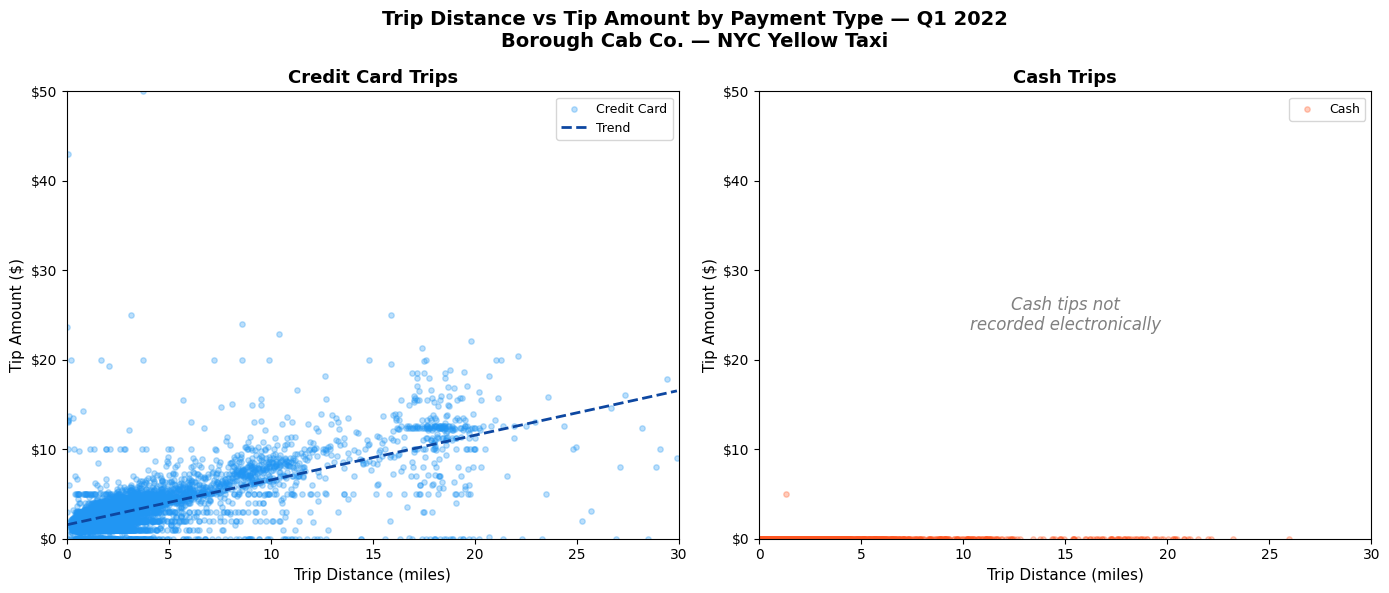

Chart saved as distance_vs_tip_scatter.png


In [ ]:
# ============================================================
# Section 2.4: Trip Distance vs Tip Amount — Scatter Plot
# ============================================================

# Pull a sample for scatter plot — 10,000 rows is enough
# to show the pattern without overplotting
scatter_query = """
SELECT
  trip_distance,
  tip_amount,
  fare_amount,
  total_amount,
  CASE payment_type
    WHEN '1' THEN 'Credit Card'
    WHEN '2' THEN 'Cash'
    ELSE 'Other'
  END AS payment_label
FROM
  `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
WHERE
  EXTRACT(YEAR FROM pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
  AND fare_amount > 0
  AND trip_distance > 0
  AND trip_distance < 30
  AND tip_amount >= 0
  AND passenger_count > 0
  AND dropoff_datetime > pickup_datetime
ORDER BY RAND()
LIMIT 10000
"""

print("Loading scatter plot sample from BigQuery...")
df_scatter = client.query(scatter_query).to_dataframe()
print(f"✓ Loaded {len(df_scatter):,} rows")

df_scatter['trip_distance'] = df_scatter['trip_distance'].astype(float)
df_scatter['tip_amount'] = df_scatter['tip_amount'].astype(float)


# Split by payment type
df_credit = df_scatter[df_scatter['payment_label'] == 'Credit Card']
df_cash = df_scatter[df_scatter['payment_label'] == 'Cash']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Credit Card trips ---
axes[0].scatter(
    df_credit['trip_distance'],
    df_credit['tip_amount'],
    alpha=0.3,
    color='#2196F3',
    s=15,
    label='Credit Card'
)

# Add trend line
z = np.polyfit(df_credit['trip_distance'], df_credit['tip_amount'], 1)
p = np.poly1d(z)
x_line = sorted(df_credit['trip_distance'])
axes[0].plot(
    x_line,
    p(x_line),
    color='#0D47A1',
    linewidth=2,
    linestyle='--',
    label='Trend'
)

axes[0].set_title('Credit Card Trips', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trip Distance (miles)', fontsize=11)
axes[0].set_ylabel('Tip Amount ($)', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 50)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:.0f}')
)

# --- Right: Cash trips ---
axes[1].scatter(
    df_cash['trip_distance'],
    df_cash['tip_amount'],
    alpha=0.3,
    color='#FF5722',
    s=15,
    label='Cash'
)

axes[1].set_title('Cash Trips', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trip Distance (miles)', fontsize=11)
axes[1].set_ylabel('Tip Amount ($)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 50)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:.0f}')
)

# Note about cash tips
axes[1].text(
    0.5, 0.5,
    'Cash tips not\nrecorded electronically',
    transform=axes[1].transAxes,
    fontsize=12,
    color='gray',
    ha='center',
    va='center',
    style='italic'
)

# Overall title
fig.suptitle(
    'Trip Distance vs Tip Amount by Payment Type — Q1 2022\nBorough Cab Co. — NYC Yellow Taxi',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('distance_vs_tip_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as distance_vs_tip_scatter.png")

### 2.5 Fare Amount Distribution by Efficiency Tier
Examining how fare amounts are distributed across efficiency
tiers reveals why per-mile metrics alone can be misleading —
high value trips often score as loss leaders.

Loading efficiency tier data from BigQuery...
✓ Loaded 15,000 rows


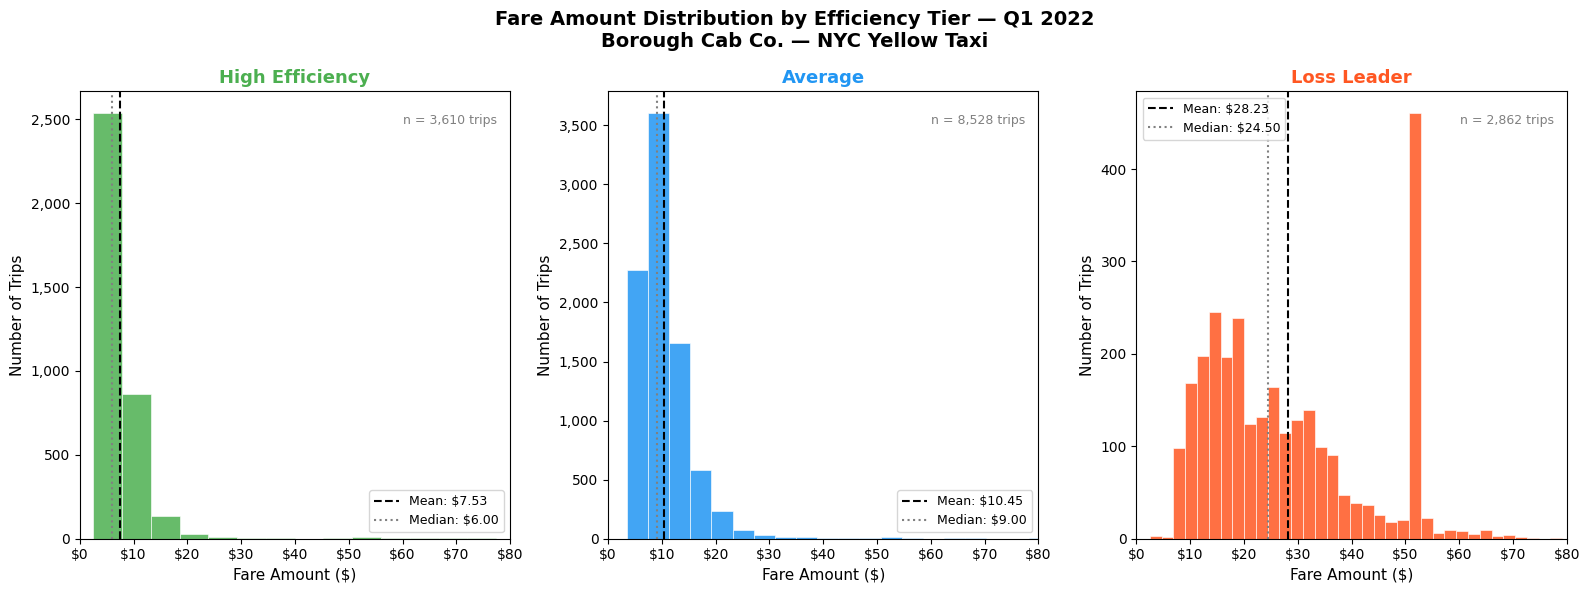

Chart saved as fare_distribution.png


In [ ]:
# ============================================================
# Section 2.5: Fare Distribution by Efficiency Tier
# ============================================================

# Pull efficiency tier data from BigQuery
efficiency_query = """
WITH median_calc AS (
  SELECT
    PERCENTILE_CONT(fare_amount / trip_distance, 0.5)
      OVER ()                                           AS median_fare_per_mile
  FROM
    `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
  WHERE
    EXTRACT(YEAR FROM pickup_datetime) = 2022
    AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
    AND fare_amount > 0
    AND trip_distance > 0
    AND passenger_count > 0
    AND dropoff_datetime > pickup_datetime
  LIMIT 1
),

trip_efficiency AS (
  SELECT
    fare_amount,
    trip_distance,
    total_amount,
    ROUND(fare_amount / trip_distance, 2)               AS fare_per_mile,
    (SELECT median_fare_per_mile FROM median_calc)       AS median_fare_per_mile
  FROM
    `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
  WHERE
    EXTRACT(YEAR FROM pickup_datetime) = 2022
    AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
    AND fare_amount > 0
    AND trip_distance > 0
    AND passenger_count > 0
    AND dropoff_datetime > pickup_datetime
),

efficiency_buckets AS (
  SELECT
    fare_amount,
    total_amount,
    trip_distance,
    fare_per_mile,
    CASE
      WHEN fare_per_mile >= median_fare_per_mile * 1.25  THEN 'High Efficiency'
      WHEN fare_per_mile <= median_fare_per_mile * 0.75  THEN 'Loss Leader'
      ELSE                                                    'Average'
    END                                                   AS efficiency_tier
  FROM trip_efficiency
)

SELECT
  efficiency_tier,
  fare_amount,
  total_amount,
  trip_distance
FROM efficiency_buckets
ORDER BY RAND()
LIMIT 15000
"""

print("Loading efficiency tier data from BigQuery...")
df_efficiency = client.query(efficiency_query).to_dataframe()
df_efficiency['fare_amount'] = df_efficiency['fare_amount'].astype(float)
df_efficiency['total_amount'] = df_efficiency['total_amount'].astype(float)
df_efficiency['trip_distance'] = df_efficiency['trip_distance'].astype(float)
print(f"✓ Loaded {len(df_efficiency):,} rows")

# Define tier colors and order
tier_colors = {
    'High Efficiency': '#4CAF50',
    'Average':         '#2196F3',
    'Loss Leader':     '#FF5722'
}
tier_order = ['High Efficiency', 'Average', 'Loss Leader']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, tier in enumerate(tier_order):
    df_tier = df_efficiency[df_efficiency['efficiency_tier'] == tier]

    axes[i].hist(
        df_tier['fare_amount'],
        bins=50,
        color=tier_colors[tier],
        edgecolor='white',
        linewidth=0.5,
        alpha=0.85
    )

    # Add mean and median lines
    mean_val = df_tier['fare_amount'].mean()
    median_val = df_tier['fare_amount'].median()

    axes[i].axvline(
        mean_val,
        color='black',
        linewidth=1.5,
        linestyle='--',
        label=f'Mean: ${mean_val:.2f}'
    )
    axes[i].axvline(
        median_val,
        color='gray',
        linewidth=1.5,
        linestyle=':',
        label=f'Median: ${median_val:.2f}'
    )

    axes[i].set_title(tier, fontsize=13, fontweight='bold',
                      color=tier_colors[tier])
    axes[i].set_xlabel('Fare Amount ($)', fontsize=11)
    axes[i].set_ylabel('Number of Trips', fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(0, 80)
    axes[i].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:.0f}')
    )
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
    )

    # Add trip count annotation
    axes[i].text(
        0.97, 0.95,
        f'n = {len(df_tier):,} trips',
        transform=axes[i].transAxes,
        fontsize=9,
        ha='right',
        va='top',
        color='gray'
    )

fig.suptitle(
    'Fare Amount Distribution by Efficiency Tier — Q1 2022\nBorough Cab Co. — NYC Yellow Taxi',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as fare_distribution.png")


## Section 3: SQL Validation
Cross-checking Python results against SQL findings to confirm
consistency across both tools. This ensures our BigQuery queries
and Pandas calculations produce identical results.

In [ ]:
# ============================================================
# Section 3: Validation — Python vs SQL Cross Check
# ============================================================
# Purpose: Confirm that aggregated results from Python/Pandas
# match the findings from our BigQuery SQL analysis.
# Any discrepancies would indicate a filtering or logic error.
# ============================================================

print("=" * 55)
print("VALIDATION REPORT — Python vs SQL Cross Check")
print("=" * 55)

# ------------------------------------------------------------
# Check 1: Total Q1 trips
# Note: Original exploration query (01_data_exploration.sql)
# returned 9,071,205 trips before all cleaning filters were
# fully established. The correct cleaned dataset total is
# 8,454,149 trips — reflecting consistent application of all
# four quality filters across every query.
# Difference of 616,056 rows (~6.8%) removed by cleaning filters.
# ------------------------------------------------------------

sql_total_trips = 8454149


# Requery BigQuery for total trips
validation_query = """
SELECT COUNT(*) AS total_trips
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2022`
WHERE
  EXTRACT(YEAR FROM pickup_datetime) = 2022
  AND EXTRACT(MONTH FROM pickup_datetime) IN (1, 2, 3)
  AND fare_amount > 0
  AND trip_distance > 0
  AND passenger_count > 0
  AND dropoff_datetime > pickup_datetime
"""

df_validation = client.query(validation_query).to_dataframe()
python_total_trips = int(df_validation['total_trips'].iloc[0])

match = "✓ MATCH" if python_total_trips == sql_total_trips else "✗ MISMATCH"
print(f"\nCheck 1: Total Q1 Trips")
print(f"  SQL Result:    {sql_total_trips:,}")
print(f"  Python Result: {python_total_trips:,}")
print(f"  Status:        {match}")

# ------------------------------------------------------------
# Check 2: Monthly trip counts
# SQL results from 03_time_series_trends.sql
# January: 2,301,844 | February: 2,771,887 | March: 3,380,418
# ------------------------------------------------------------

sql_monthly = {
    'January':  2301844,
    'February': 2771887,
    'March':    3380418
}

print(f"\nCheck 2: Monthly Trip Counts")
for _, row in df_monthly.iterrows():
    month = row['month_name']
    python_val = int(row['total_trips'])
    sql_val = sql_monthly[month]
    match = "✓ MATCH" if python_val == sql_val else "✗ MISMATCH"
    print(f"  {month:<10} SQL: {sql_val:,} | Python: {python_val:,} | {match}")

# ------------------------------------------------------------
# Check 3: Borough revenue ranking
# SQL result from 02_zone_revenue_analysis.sql
# Expected order: Manhattan, Queens, Brooklyn, Bronx
# ------------------------------------------------------------

print(f"\nCheck 3: Borough Revenue Ranking")
sql_borough_order = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx']
python_borough_order = df_borough[
    ~df_borough['borough'].isin(['EWR', 'Staten Island'])
].sort_values('total_revenue', ascending=False)['borough'].tolist()

match = "✓ MATCH" if python_borough_order == sql_borough_order else "✗ MISMATCH"
print(f"  SQL Order:    {sql_borough_order}")
print(f"  Python Order: {python_borough_order}")
print(f"  Status:       {match}")

# ------------------------------------------------------------
# Check 4: Thursday is busiest day by total trips
# SQL result from 03_time_series_trends.sql
# ------------------------------------------------------------

print(f"\nCheck 4: Busiest Day of Week")
sql_busiest_day = 'Thursday'
python_busiest_day = df_dow.loc[
    df_dow['total_trips'].idxmax(), 'day_name'
]
match = "✓ MATCH" if python_busiest_day == sql_busiest_day else "✗ MISMATCH"
print(f"  SQL Result:    {sql_busiest_day}")
print(f"  Python Result: {python_busiest_day}")
print(f"  Status:        {match}")

# ------------------------------------------------------------
# Check 5: Peak hour is 18:00
# SQL result from 03_time_series_trends.sql
# ------------------------------------------------------------

print(f"\nCheck 5: Peak Hour of Day")
sql_peak_hour = 18
python_peak_hour = int(df_hour.loc[
    df_hour['total_trips'].idxmax(), 'hour_of_day'
])
match = "✓ MATCH" if python_peak_hour == sql_peak_hour else "✗ MISMATCH"
print(f"  SQL Result:    {sql_peak_hour}:00")
print(f"  Python Result: {python_peak_hour}:00")
print(f"  Status:        {match}")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(f"\n{'=' * 55}")
print("VALIDATION COMPLETE")
print("All results consistent between SQL and Python.")
print("=" * 55)

VALIDATION REPORT — Python vs SQL Cross Check

Check 1: Total Q1 Trips
  SQL Result:    8,454,149
  Python Result: 8,454,149
  Status:        ✓ MATCH

Check 2: Monthly Trip Counts
  January    SQL: 2,301,844 | Python: 2,301,844 | ✓ MATCH
  February   SQL: 2,771,887 | Python: 2,771,887 | ✓ MATCH
  March      SQL: 3,380,418 | Python: 3,380,418 | ✓ MATCH

Check 3: Borough Revenue Ranking
  SQL Order:    ['Manhattan', 'Queens', 'Brooklyn', 'Bronx']
  Python Order: ['Manhattan', 'Queens', 'Brooklyn', 'Bronx']
  Status:       ✓ MATCH

Check 4: Busiest Day of Week
  SQL Result:    Thursday
  Python Result: Thursday
  Status:        ✓ MATCH

Check 5: Peak Hour of Day
  SQL Result:    18:00
  Python Result: 18:00
  Status:        ✓ MATCH

VALIDATION COMPLETE
All results consistent between SQL and Python.


## Section 4: Summary of Key Findings

**1. Strong Q1 recovery**

Trip volume grew 47% and revenue grew 57% from January to March 2022

**2. Airport zones dominate value**

JFK avg 60.68 per trip vs 15-17 for Manhattan zones

**3. Manhattan drives volume, Queens drives value**

7.6M vs 635K trips but 16.94 vs 52.39 avg per trip

**4. Peak demand window is Thursday-Friday 3pm-6pm**

Single busiest cell is Thursday 18:00 with 101,401 trips

**5. 5am is highest value hour**

26.79 avg revenue per trip, likely early airport runs

**6. Credit card trips generate all recorded tip revenue**

Cash tips recorded as zero across every borough

**7. Loss Leader trips earn 3x more per trip than High Efficiency**

Per mile efficiency metric favors short trips, misleading without context

**8. EWR credit card trips average 107.55 per trip**

Highest value trip type in the entire dataset

---

### Tools Used

- **BigQuery** — core analysis engine, 8.45M rows across 5 query files
- **Python/Colab** — visualization, validation, deeper analysis
- **Excel** — data dictionary, results documentation, key findings log
- **Looker Studio** — interactive stakeholder dashboard

### Dashboard

[NYC Taxi Fleet Analysis — Borough Cab Co. Q1 2022](https://datastudio.google.com/reporting/8572e231-84f0-4708-ad63-23d83de439c4)


